# N3 — LiDAR 3D Object Detection & Tracking

This notebook builds a complete **3D object detection and tracking pipeline** from raw LiDAR point clouds — no pre-trained detectors, just geometry and clustering.

**What you will learn:**
1. **Ground plane removal** using surface normal estimation
2. **Euclidean clustering** (DBSCAN) to segment individual obstacles
3. **3D bounding box** extraction from point clusters
4. **Multi-object tracking** with the same Kalman filter from N2 — detect in 3D, track in the bird's-eye-view plane
5. **Future state prediction** — where will each tracked object be in the next few timesteps?

> **Note:** the notebook cells contain only the perception math. All plotting and
> video-rendering code lives in the companion module **`n3_viz.py`** (imported as
> `viz`) — open it if you want to see how a figure is drawn, but you never need
> to touch it to follow the pipeline.

**Pipeline overview:**

```
 Raw LiDAR ──► ROI Crop ──► Ground Removal ──► Clustering ──► 3D Bboxes
  (120k pts)   (~30k pts)   (normal filter)     (DBSCAN)     (per object)
                                                                  │
                                                                  ▼
  Tracking Video ◄── Kalman Predict/Update ◄── Hungarian Assignment
  (BEV + Camera)     (BEV constant velocity)    (distance cost)
```

In [1]:
%pip install numpy matplotlib pykitti scipy scikit-learn imageio[ffmpeg] transformers torch torchvision --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: C:\Users\Joey\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.spatial import cKDTree
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import DBSCAN
import pykitti
import imageio
import os
from io import BytesIO

import n3_viz as viz   # all plotting/video code lives here — notebook stays math-only

np.random.seed(42)

data = pykitti.raw("kitti_data", "2011_09_26", "0005")
num_frames = len(data.timestamps)

# Timestep between scans (~0.1 s) — becomes dt in the Kalman motion model
try:
    dt = (data.timestamps[1] - data.timestamps[0]).total_seconds()
except Exception:
    dt = 0.1

# Projection: Velodyne → Camera 2 image.
# Composing extrinsics (T) and intrinsics (P2) gives ONE 3x4 matrix that
# takes a 3D LiDAR point straight to image pixels — used throughout for
# drawing boxes on the camera view and for the road filter.
T_cam_velo = np.array(data.calib.T_cam0_velo)  # (4,4) includes R_rect
P2 = np.array(data.calib.P_rect_20)             # (3,4)
M_proj = P2 @ T_cam_velo                         # (3,4)

velo_0 = data.get_velo(0)
print(f"KITTI drive 0005: {num_frames} frames at {1/dt:.0f} Hz (dt = {dt:.3f} s)")
print(f"Frame 0: {velo_0.shape[0]:,} points  [X, Y, Z, reflectance]")
print(f"X range: [{velo_0[:,0].min():.1f}, {velo_0[:,0].max():.1f}] m  (forward / back)")
print(f"Y range: [{velo_0[:,1].min():.1f}, {velo_0[:,1].max():.1f}] m  (left / right)")
print(f"Z range: [{velo_0[:,2].min():.1f}, {velo_0[:,2].max():.1f}] m  (up / down)")

### How the plotting works

All figures are drawn with **matplotlib** by functions in [`n3_viz.py`](n3_viz.py); the notebook computes results and hands them over. Two patterns cover everything:

- **Static figures** (`show_raw_bev`, `show_normals`, `show_ground_removal`, `show_detections_bev`, `show_road_filtering`, `show_tracking_frames`) — `plt.subplots()` lays out the panels (e.g. camera view next to bird's-eye view), point clouds are drawn with `ax.scatter` (colored by height or cluster label), images with `ax.imshow`, and 3D boxes as their 12 projected edges via `ax.plot`. `plt.show()` renders the figure inline.
- **Video rendering** (`render_tracking_video`) — the same matplotlib drawing runs once per frame in a loop: draw the figure, rasterize it to an RGB array (`fig.canvas`), and append it to an `imageio` ffmpeg writer. The result is a real `.mp4` instead of an inline figure, so 154 frames stay smooth and the notebook file stays small.

The bird's-eye view is just a 2D scatter of the LiDAR $(x, y)$ coordinates — "looking down" requires no 3D plotting, which is why everything here uses ordinary 2D matplotlib axes.

## 1. Bird's-Eye View of Raw LiDAR

The Velodyne HDL-64E returns ~120,000 points per scan in the sensor frame: **X** forward, **Y** left, **Z** up. We crop to a forward-facing region of interest and plot a bird's-eye view — looking straight down from above.

In [ ]:
# Region of interest in the Velodyne frame (meters):
# x = 2–60 m ahead, y = ±25 m left/right, z = just below road to +1.5 m.
# Cuts ~120k points down to ~30k and discards everything behind the car.
ROI = {'x': (2, 60), 'y': (-25, 25), 'z': (-2.5, 1.5)}

def crop_roi(points, roi=ROI):
    # One boolean range-test per axis, AND-ed together
    m = ((points[:, 0] >= roi['x'][0]) & (points[:, 0] <= roi['x'][1]) &
         (points[:, 1] >= roi['y'][0]) & (points[:, 1] <= roi['y'][1]) &
         (points[:, 2] >= roi['z'][0]) & (points[:, 2] <= roi['z'][1]))
    return points[m]

pts_roi = crop_roi(velo_0[:, :3])

viz.show_raw_bev(np.array(data.get_cam2(0)), pts_roi)

print(f"ROI crop: {len(pts_roi):,} / {velo_0.shape[0]:,} points "
      f"({100 * len(pts_roi) / velo_0.shape[0]:.0f}%)")

## 2. Ground Plane Removal via Surface Normal Estimation

To detect obstacles we first remove the ground. The approach:

1. **Height pre-filter** — points near ground level ($z \in [-2.5, -0.8]$ m in the Velodyne frame) are ground candidates
2. **Voxel downsample** — reduce candidates to one point per 0.2 m voxel for speed
3. **Estimate surface normals** — for each point's local neighborhood, the normal is the eigenvector of the **smallest eigenvalue** of the local covariance matrix:

$$\mathbf{n} = \text{eigvec}_{\min}\left(\frac{1}{k}\sum_{i=1}^{k}(\mathbf{p}_i - \bar{\mathbf{p}})(\mathbf{p}_i - \bar{\mathbf{p}})^\top\right)$$

4. **Filter by verticality** — ground normals point nearly straight up: $|\mathbf{n}_z| > 0.85$

> **Why the eigenvector gives the normal.** What we really want is the *best-fit
> plane* through the neighborhood — the plane that minimizes the perpendicular
> distances from the points to it. The eigendecomposition is just a clean trick
> for finding it: the eigenvectors of the covariance matrix are the directions
> the points spread along, and their eigenvalues are how much spread there is in
> each. The **two largest** span the plane (the directions of most spread); the
> **smallest** points across it — the direction of *least* spread, which is
> exactly the perpendicular we minimized. So the smallest-eigenvalue eigenvector
> **is** the surface normal.

> **Numerical note — the `+ np.eye(3) * 1e-6` ridge in `estimate_normals`.**
> The covariance matrix above can be **singular** when a point's neighbors are
> degenerate — all collinear, perfectly coplanar, or duplicated, which happens
> often on sparse LiDAR returns. A singular (or near-singular) matrix has a zero
> eigenvalue, and feeding one to `np.linalg.eigh` can yield unstable eigenvectors
> or fail outright. Adding a tiny multiple of the identity ($10^{-6}\mathbf{I}$) —
> known as **Tikhonov regularization** or a *ridge* — lifts every eigenvalue by
> $10^{-6}$, guaranteeing the matrix is strictly positive-definite so the
> eigendecomposition always succeeds. The value is small enough not to distort
> the real local geometry (and therefore the estimated normal).

In [ ]:
def estimate_normals(points, k=20):
    '''Estimate a surface normal for every point via local PCA.

    Idea: look at each point's k nearest neighbors. If they lie on a flat
    surface, the direction of LEAST variance is perpendicular to that
    surface — that direction is the normal.
    '''
    # Find each point's k nearest neighbors (KD-tree = fast spatial lookup)
    tree = cKDTree(points)
    _, idx = tree.query(points, k=min(k, len(points)))
    neighborhoods = points[idx]                                   # (N, k, 3)

    # Center each neighborhood on its mean so we measure pure spread
    centered = neighborhoods - neighborhoods.mean(axis=1, keepdims=True)

    # One 3x3 covariance matrix per point — describes how its neighborhood
    # spreads in each direction (einsum = batched outer products, all N at once)
    covs = np.einsum('nki,nkj->nij', centered, centered) / (k - 1)  # (N, 3, 3)
    covs += np.eye(3)[None] * 1e-6                # tiny ridge so eigh never fails on degenerate patches

    # Eigendecomposition: eigenvectors = principal directions of the spread.
    # eigh sorts eigenvalues ascending, so column 0 = direction of LEAST
    # variance = the surface normal.
    eigenvalues, eigenvectors = np.linalg.eigh(covs)
    normals = eigenvectors[:, :, 0]

    # A normal is ambiguous (n vs −n) — flip all to point up, so a flat
    # road always gives n_z ≈ +1
    normals[normals[:, 2] < 0] *= -1
    return normals


def remove_ground(points, k=20, z_range=(-2.5, -0.8),
                  normal_thresh=0.85, voxel_size=0.2):
    '''Return a boolean mask: True = ground point.

    Two-stage filter: (1) only points near ground HEIGHT are candidates,
    (2) of those, only points on a locally FLAT surface (vertical normal)
    are kept as ground. Height alone would also delete car bumpers and
    wheel wells; flatness alone would delete car roofs.
    '''
    # --- Stage 1: height gate ---
    # The Velodyne sits ~1.73 m above the road, so ground points live
    # around z ≈ −1.7 m in the sensor frame
    cand_mask = (points[:, 2] >= z_range[0]) & (points[:, 2] <= z_range[1])
    if cand_mask.sum() < k:
        return np.zeros(len(points), dtype=bool)   # too few candidates → remove nothing

    cand_pts = points[cand_mask]

    # --- Voxel downsample: one representative point per 20 cm cube ---
    # Normal estimation is the expensive step; running it on ~5k voxels
    # instead of ~30k raw points is much faster with the same result.
    # `inverse` remembers which voxel each original point fell into, so the
    # per-voxel verdict can be broadcast back to every point afterwards.
    vox_keys = np.floor(cand_pts / voxel_size).astype(np.int64)
    _, uniq_idx, inverse = np.unique(vox_keys, axis=0,
                                     return_index=True, return_inverse=True)
    downsampled = cand_pts[uniq_idx]

    k_use = min(k, len(downsampled) - 1)
    if k_use < 4:                                  # not enough voxels for a meaningful plane fit
        return np.zeros(len(points), dtype=bool)

    # --- Stage 2: flatness gate ---
    # A vertical normal (|n_z| > 0.85, i.e. within ~32° of straight up)
    # means the local surface is ground-like
    normals = estimate_normals(downsampled, k=k_use)
    is_ground_voxel = np.abs(normals[:, 2]) > normal_thresh

    # Broadcast each voxel's verdict back to ALL candidate points in it
    is_ground_cand = is_ground_voxel[inverse]

    # Map candidate indices back into the ORIGINAL full point array
    ground_mask = np.zeros(len(points), dtype=bool)
    ground_mask[np.where(cand_mask)[0][is_ground_cand]] = True
    return ground_mask

print("Functions defined: estimate_normals(), remove_ground()")

### Visualizing Surface Normals

Before we apply the ground filter, let's build intuition for what surface normals look like on real LiDAR data.

Every point's **surface normal** is estimated from its local neighborhood using PCA — the normal is the direction of *least variance* among nearby points. For a flat road surface, normals point nearly straight up ($|n_z| \approx 1$). For vertical surfaces like cars, walls, or poles, normals point sideways ($|n_z| \approx 0$).

The plots below show normals as arrows on a small patch of the scene, colored by **verticality** $|n_z|$:
- **Green** → vertical normal (ground-like)
- **Red** → horizontal normal (obstacle-like)
- The dashed line at $|n_z| = 0.85$ is our classification threshold

In [ ]:
# Estimate normals on a patch in front of the vehicle (road + obstacles),
# subsampled so individual arrows stay visible
# Box select an x = 5-25 m ahead, y = +/-10 m window so we get a mix of
# flat road and a few cars/poles in one frame
patch_mask = ((pts_roi[:, 0] > 5) & (pts_roi[:, 0] < 25) &
              (pts_roi[:, 1] > -10) & (pts_roi[:, 1] < 10))
patch_pts = pts_roi[patch_mask]

# Fixed seed -> the same 800 points are drawn every run, so the figure is
# reproducible. ~800 arrows is dense enough to read but not a solid blob.
np.random.seed(42)
n_vis = min(800, len(patch_pts))
vis_idx = np.random.choice(len(patch_pts), n_vis, replace=False)
vis_pts = patch_pts[vis_idx]

# One normal per visualized point; verticality = |n_z| in [0, 1]
# (1 = points straight up = flat ground, 0 = horizontal = obstacle face)
normals_vis = estimate_normals(vis_pts, k=15)
verticality = np.abs(normals_vis[:, 2])

viz.show_normals(vis_pts, normals_vis, verticality)

# Count how many of this patch's points pass the ground threshold (|n_z| > 0.85)
n_vert = (verticality > 0.85).sum()
print(f"Patch: {n_vis} points  |  Vertical (|n_z| > 0.85): {n_vert} "
      f"({100*n_vert/n_vis:.0f}%)  |  Non-vertical: {n_vis - n_vert}")
print("Green arrows = ground (pointing up)  |  Red arrows = obstacles (pointing sideways)")

In [ ]:
# --- Apply ground removal ---
ground_mask = remove_ground(pts_roi)
ground = pts_roi[ground_mask]
non_ground = pts_roi[~ground_mask]      # <-- everything downstream (clustering) uses this


def project_points(pts_3d, M, img_shape):
    """Project 3D Velodyne points into the camera image: u = (M·p) / depth."""
    # Homogeneous coordinates: append a 1 so the 3x4 matrix M can rotate,
    # translate AND apply the camera intrinsics in a single multiply
    hom = np.hstack([pts_3d, np.ones((len(pts_3d), 1))])
    proj = (M @ hom.T).T
    depth = proj[:, 2]                  # distance along the camera's optical axis
    valid = depth > 0.5                 # drop points behind or right at the camera
    pts_2d = np.zeros((len(pts_3d), 2))
    if valid.any():
        # Perspective divide: pixel (u, v) = (x, y) / depth — this is what
        # makes far-away points land near the image center
        pts_2d[valid] = proj[valid, :2] / proj[valid, 2:3]
    # Keep only pixels that actually land inside the image bounds
    h, w = img_shape[:2]
    in_img = valid & (pts_2d[:, 0] >= 0) & (pts_2d[:, 0] < w) & \
             (pts_2d[:, 1] >= 0) & (pts_2d[:, 1] < h)
    return pts_2d, in_img, depth


# Project both point sets onto the camera image to sanity-check the split:
# ground points should paint the road, non-ground points the cars/poles
img_0 = np.array(data.get_cam2(0))
uv_g, vis_g, d_g = project_points(ground, M_proj, img_0.shape)
uv_ng, vis_ng, d_ng = project_points(non_ground, M_proj, img_0.shape)

viz.show_ground_removal(img_0, ground, non_ground, uv_g, vis_g, uv_ng, vis_ng)

print(f"Ground: {len(ground):,} pts  |  Non-ground: {len(non_ground):,} pts")

## 3. Euclidean Clustering & 3D Bounding Boxes

Non-ground points are grouped into clusters using **DBSCAN** — a density-based algorithm that is equivalent to Euclidean clustering:

- Two points are **neighbors** if their distance $< \varepsilon$
- A cluster needs at least `min_samples` connected neighbors
- Points that don't belong to any cluster are labeled **noise** (−1)

After clustering, we fit **axis-aligned 3D bounding boxes** and filter by physical dimensions to keep vehicle-sized objects (height 0.3–3.5 m, length 0.5–15 m).

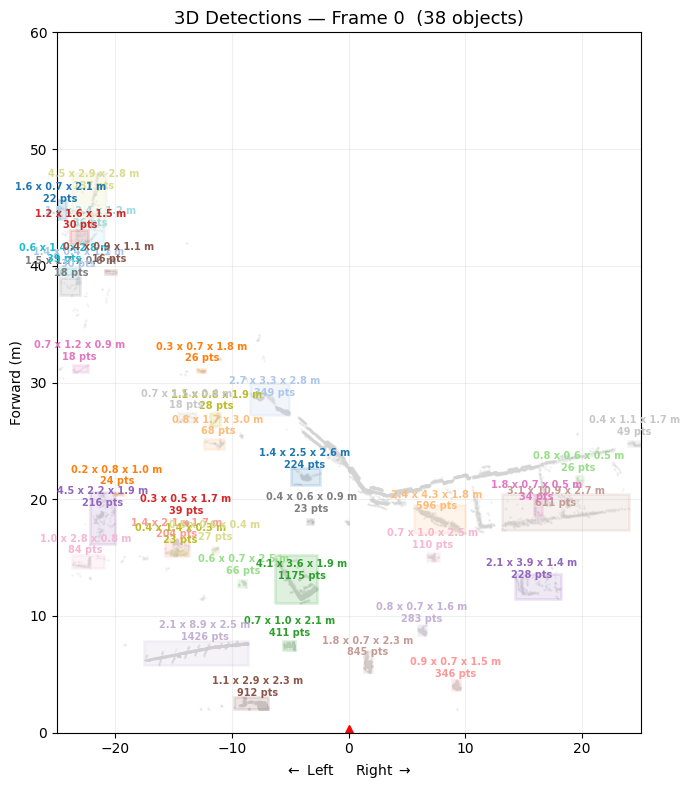

  Object 0: center=(21.9, 3.8, -0.5)  size=1.4 x 2.5 x 2.6 m  (224 pts)
  Object 1: center=(28.1, 6.4, 0.1)  size=2.7 x 3.3 x 2.8 m  (349 pts)
  Object 2: center=(31.0, 12.6, 0.8)  size=0.3 x 0.7 x 1.8 m  (26 pts)
  Object 3: center=(24.8, 11.2, -0.3)  size=0.8 x 1.7 x 3.0 m  (68 pts)
  Object 4: center=(7.5, 5.0, -0.4)  size=0.7 x 1.0 x 2.1 m  (411 pts)
  Object 5: center=(12.8, 9.0, -0.6)  size=0.6 x 0.7 x 2.5 m  (66 pts)
  Object 6: center=(18.0, 13.9, 0.4)  size=0.3 x 0.5 x 1.7 m  (39 pts)
  Object 7: center=(15.9, 14.8, 0.3)  size=1.4 x 2.1 x 1.7 m  (204 pts)
  Object 8: center=(18.7, 21.1, 0.5)  size=4.5 x 2.2 x 1.9 m  (216 pts)
  Object 9: center=(7.1, 12.3, -1.2)  size=2.1 x 8.9 x 2.5 m  (1426 pts)
  Object 10: center=(2.4, 7.8, -0.4)  size=1.1 x 2.9 x 2.3 m  (912 pts)
  Object 11: center=(18.6, -17.7, -0.8)  size=3.1 x 10.9 x 2.7 m  (611 pts)
  Object 12: center=(19.1, -16.1, 1.0)  size=1.8 x 0.7 x 0.5 m  (34 pts)
  Object 13: center=(15.1, -7.2, -0.3)  size=0.7 x 1.0 x 2.5 m 

In [7]:
def cluster_and_extract(points, eps=0.7, min_samples=10,
                        min_pts=15, max_pts=8000,
                        min_h=0.3, max_h=3.5, min_l=0.5, max_l=15.0):
    '''Group non-ground points into object clusters and fit a 3D box to each.

    eps / min_samples     -> DBSCAN: two points are neighbors if closer than
                             eps (m); a cluster needs min_samples neighbors
    min_pts / max_pts     -> reject clusters with too few points (noise) or
                             too many (walls, vegetation)
    min_h..max_l          -> keep only vehicle-sized boxes (meters)
    '''
    if len(points) < min_samples:
        return [], np.full(len(points), -1)

    # --- Step 1: cluster ---
    # DBSCAN assigns every point a cluster label; -1 means "noise"
    # (the point has no dense neighborhood and belongs to no object)
    labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(points)

    detections = []
    for lab in set(labels):
        if lab == -1:
            continue                       # skip noise points

        cluster = points[labels == lab]    # all points in this cluster

        # --- Step 2: size sanity check on the point count ---
        if len(cluster) < min_pts or len(cluster) > max_pts:
            continue

        # --- Step 3: fit an axis-aligned 3D bounding box ---
        # min/max over each axis gives the two opposite box corners
        bbox_min = cluster.min(axis=0)
        bbox_max = cluster.max(axis=0)
        dims = bbox_max - bbox_min         # [length_x, width_y, height_z]

        # --- Step 4: keep only vehicle-sized boxes ---
        # h = vertical extent, l = longest horizontal extent
        h, l = dims[2], max(dims[0], dims[1])
        if h < min_h or h > max_h or l < min_l or l > max_l:
            continue

        # --- Step 5: package as a detection ---
        # centroid = mean of the cluster points -> this becomes the
        # measurement z that the Kalman filter consumes in section 5
        detections.append({
            'centroid': cluster.mean(axis=0),
            'bbox_min': bbox_min,
            'bbox_max': bbox_max,
            'dims': dims,
            'n_points': len(cluster),
        })
    return detections, labels


# --- Apply to frame 0 ---
detections_0, labels_0 = cluster_and_extract(non_ground)

viz.show_detections_bev(non_ground, detections_0,
                        title=f'3D Detections — Frame 0  ({len(detections_0)} objects)')

for i, d in enumerate(detections_0):
    print(f"  Object {i}: center=({d['centroid'][0]:.1f}, {d['centroid'][1]:.1f}, "
          f"{d['centroid'][2]:.1f})  size={d['dims'][0]:.1f} x {d['dims'][1]:.1f} x "
          f"{d['dims'][2]:.1f} m  ({d['n_points']} pts)")

## 4. Full Detection Pipeline

Wrap ground removal → clustering → bounding box extraction into one function.

In [ ]:
def detect_objects_3d(velo_points, roi=ROI):
    '''Raw scan -> list of 3D detections. One call per LiDAR frame.'''
    pts = crop_roi(velo_points[:, :3], roi)        # 1. keep forward-facing ROI
    if len(pts) == 0:
        return []
    ground_mask = remove_ground(pts)               # 2. drop the road surface
    non_ground = pts[~ground_mask]
    if len(non_ground) < 10:
        return []
    detections, _ = cluster_and_extract(non_ground)  # 3. DBSCAN + 3D boxes
    return detections

# Quick test
for idx in [0, 50, 100, 150]:
    if idx < num_frames:
        dets = detect_objects_3d(data.get_velo(idx))
        print(f"Frame {idx:3d}: {len(dets)} objects detected")

### Road Surface Filtering — Connecting N1 to N3

Not all detected objects matter for driving — a cluster on the sidewalk or a building wall should be ignored. We bring in the **SegFormer road segmentation** from N1 to identify the drivable surface.

For each 3D detection, we project the **bottom center** of its bounding box onto the camera image. If that pixel falls on the road mask, the object is kept; otherwise it's filtered out.

This connects the two notebooks: N1's semantic understanding of *what the road is* feeds into N3's tracking of *what's moving on it*.

In [ ]:
import torch
import torch.nn.functional as F_nn
from transformers import SegformerForSemanticSegmentation, SegformerImageProcessor
from PIL import Image

seg_processor = SegformerImageProcessor.from_pretrained(
    "nvidia/segformer-b0-finetuned-cityscapes-1024-1024")
seg_model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/segformer-b0-finetuned-cityscapes-1024-1024")
seg_model.eval()
print("SegFormer-B0 loaded (same road segmentation model from N1)")


def get_road_mask(image):
    '''Camera image -> boolean mask of drivable-road pixels.'''
    inputs = seg_processor(images=Image.fromarray(image), return_tensors="pt")
    with torch.no_grad():
        logits = seg_model(**inputs).logits
    # The model outputs a low-res class map — upsample back to image size
    upsampled = F_nn.interpolate(logits, size=image.shape[:2],
                                  mode="bilinear", align_corners=False)
    # Cityscapes class 0 = "road"
    return upsampled.argmax(dim=1).squeeze().cpu().numpy() == 0


def filter_on_road(detections, road_mask, M_proj):
    """Keep detections whose base center projects onto road pixels."""
    on_road = []
    h, w = road_mask.shape
    for det in detections:
        # Bottom center of the 3D box: centroid (x, y) at the box's lowest z.
        # We test the BASE because that's the part touching the road —
        # the centroid itself sits ~1 m up and would project onto the
        # object's own body, not the surface under it.
        base = np.array([det['centroid'][0], det['centroid'][1],
                         det['bbox_min'][2], 1.0])
        proj = M_proj @ base
        if proj[2] <= 0:                # behind the camera — can't test, drop it
            continue
        # Perspective divide -> pixel, then a single mask lookup decides
        u, v = int(round(proj[0] / proj[2])), int(round(proj[1] / proj[2]))
        if 0 <= u < w and 0 <= v < h and road_mask[v, u]:
            on_road.append(det)
    return on_road


# Precompute road masks for all frames
print(f"Computing road masks for {num_frames} frames (this may take a few minutes)...")
road_masks = []
for i in range(num_frames):
    if i % 20 == 0:
        print(f"  Frame {i}/{num_frames}")
    road_masks.append(get_road_mask(np.array(data.get_cam2(i))))
print(f"Done — {num_frames} road masks cached")

# --- Compare: all detections vs road-only on frame 0 ---
all_dets_0 = detect_objects_3d(data.get_velo(0))
road_dets_0 = filter_on_road(all_dets_0, road_masks[0], M_proj)

viz.show_road_filtering(np.array(data.get_cam2(0)), road_masks[0],
                        all_dets_0, road_dets_0)

print(f"Road filtering: {len(all_dets_0)} detections → {len(road_dets_0)} on-road objects")

In [ ]:
# Estimate ground plane height from LiDAR (same approach as N1):
# 5th percentile of z in a patch right in front of the car ≈ road height
ground_candidates = velo_0[(velo_0[:, 0] > 3) & (velo_0[:, 0] < 25) &
                           (np.abs(velo_0[:, 1]) < 6)]
z_ground = np.percentile(ground_candidates[:, 2], 5)

def backproject_to_ground(pixels_uv, M, z_ground):
    """Back-project 2D pixels to 3D ground plane (from N1).

    Projection normally loses depth — but if we ASSUME the pixel lies on
    the flat ground (z = z_ground), the projection equations
    u·depth = M·[X, Y, z_ground, 1] become 2 linear equations in the 2
    unknowns (X, Y). Solve that 2x2 system per pixel and 3D is recovered.
    """
    u = pixels_uv[:, 0].astype(np.float64)
    v = pixels_uv[:, 1].astype(np.float64)
    # Constant terms: the known-z part of the projection folded into scalars
    a = M[0, 2] * z_ground + M[0, 3]
    b = M[1, 2] * z_ground + M[1, 3]
    c = M[2, 2] * z_ground + M[2, 3]
    # 2x2 system A·[X, Y]ᵀ = rhs, one per pixel (all vectorized)
    A00 = M[0, 0] - u * M[2, 0]
    A01 = M[0, 1] - u * M[2, 1]
    A10 = M[1, 0] - v * M[2, 0]
    A11 = M[1, 1] - v * M[2, 1]
    rhs0 = u * c - a
    rhs1 = v * c - b
    # Cramer's rule; det = 0 means the ray is parallel to the ground (horizon)
    det = A00 * A11 - A01 * A10
    det[det == 0] = np.nan
    X = (rhs0 * A11 - rhs1 * A01) / det
    Y = (A00 * rhs1 - A10 * rhs0) / det
    return np.stack([X, Y, np.full_like(X, z_ground)], axis=1)

# Back-project road masks to BEV with camera colors for every frame —
# this paints the actual road texture under the BEV tracking plots
print(f"Back-projecting road surfaces for {num_frames} frames...")
road_bev = []
road_bev_colors = []
for i in range(num_frames):
    img_i = np.array(data.get_cam2(i))
    rv, ru = np.where(road_masks[i])           # all road pixels in this frame
    if len(rv) > 0:
        step = max(1, len(rv) // 8000)          # subsample to ~8k pixels for speed
        px = np.stack([ru[::step], rv[::step]], axis=1)
        colors = img_i[rv[::step], ru[::step]] / 255.0   # carry each pixel's RGB along
        pts = backproject_to_ground(px, M_proj, z_ground)
        # Drop horizon artifacts and anything outside the BEV plot range
        valid = (np.isfinite(pts[:, 0]) & (pts[:, 0] > 0) & (pts[:, 0] < 60) &
                 (np.abs(pts[:, 1]) < 25))
        road_bev.append(pts[valid])
        road_bev_colors.append(colors[valid])
    else:
        road_bev.append(np.empty((0, 3)))
        road_bev_colors.append(np.empty((0, 3)))
    if i % 20 == 0:
        print(f"  Frame {i}/{num_frames}")
print(f"Done — road BEV with camera colors cached for {num_frames} frames")

In [ ]:
# Ego-motion compensation: transform all frames to frame 0's coordinate system
# using GPS/IMU poses so stationary objects don't appear to move.
# Without this, the car's own driving would leak into every tracked velocity —
# a parked car would seem to move backwards at our speed.

# Fixed mounting transform between the Velodyne and the IMU (from the KITTI
# calibration file calib_imu_to_velo.txt — a constant property of the car)
T_velo_imu = np.eye(4)
T_velo_imu[:3, :3] = np.array([
    9.999976e-01, 7.553071e-04, -2.035826e-03,
    -7.854027e-04, 9.998898e-01, -1.482298e-02,
    2.024406e-03, 1.482454e-02, 9.998881e-01
]).reshape(3, 3)
T_velo_imu[:3, 3] = np.array([-8.086759e-01, 3.195559e-01, -7.997231e-01])

T_imu_velo = np.linalg.inv(T_velo_imu)
oxts_all = list(data.oxts)                       # GPS/IMU reading per frame
T_w0_inv = np.linalg.inv(oxts_all[0].T_w_imu)    # world -> frame-0 IMU

ego_poses = []
for i in range(num_frames):
    T_wi = oxts_all[i].T_w_imu                   # frame-i IMU -> world
    # Chain (read right to left): velo_i -> imu_i -> world -> imu_0 -> velo_0
    # Result: one matrix that moves frame-i LiDAR points into frame 0's frame
    ego_poses.append(T_velo_imu @ T_w0_inv @ T_wi @ T_imu_velo)

# Ego position/heading per frame, used to draw the car in the BEV plots
ego_positions = np.array([T[:3, 3] for T in ego_poses])
ego_headings = np.array([np.arctan2(T[1, 0], T[0, 0]) for T in ego_poses])

total_dist = np.sum(np.linalg.norm(np.diff(ego_positions, axis=0), axis=1))
print(f"Ego poses computed for {num_frames} frames")
print(f"Total distance: {total_dist:.1f} m  |  "
      f"Heading: [{np.degrees(ego_headings.min()):.1f}°, {np.degrees(ego_headings.max()):.1f}°]")

## 5. Multi-Object Tracking with the Kalman Filter from N2

We track detected objects across frames using the **same 4-state filter built in N2** — one filter per object.

**State vector**: $\hat{x} = [x,\; y,\; v_x,\; v_y]^\top$ — position and velocity on the ground plane (bird's-eye view)

**State transition** (constant velocity) and **measurement** (position only) — identical to N2's 2D tracker:

$$F = \begin{bmatrix} 1 & 0 & \Delta t & 0 \\ 0 & 1 & 0 & \Delta t \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{bmatrix}, \qquad H = \begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \end{bmatrix}$$

**Why not track z?** Vehicles don't move vertically — a filtered $v_z$ would just be noise. The detections stay fully 3D: each track keeps its latest detection's height and 3D bounding box, which is what gets drawn on the camera view. We *detect in 3D, track in the BEV plane* — a common pattern in real perception stacks.

**Data association**: Hungarian algorithm on BEV distance between predicted track positions and new detection centroids — same idea as IoU matching in N4, but in metric space. A track is **confirmed** after 3 hits and **deleted** after 5 consecutive misses.

**Ego-motion compensation**: before feeding detections to the tracker, we transform each frame's coordinates into a fixed world frame (frame 0) using GPS/IMU poses. This prevents the car's own rotation and translation from contaminating tracked velocities — stationary objects stay still, and prediction arrows reflect true object motion.

In [ ]:
class TrackBEV:
    '''One Kalman-filtered object track — the same 4-state [x, y, vx, vy]
    constant-velocity filter from N2, running in the world-frame BEV plane.
    The z coordinate and 3D bounding box come from the latest detection
    (used for the camera overlay), not from the filter.'''

    _next_id = 0

    def __init__(self, detection, dt):
        self.id = TrackBEV._next_id
        TrackBEV._next_id += 1

        # --- Initial state: we KNOW where the object is, but not how fast ---
        # Position comes from the first detection; velocity starts at 0.
        # P encodes that asymmetry: low position uncertainty (1 m²) vs high
        # velocity uncertainty (10 m²/s²) — the filter will fix velocity
        # itself within a few updates as it sees the object move.
        cx, cy, cz = detection['centroid']
        self.x = np.array([cx, cy, 0.0, 0.0])
        self.P = np.diag([1.0, 1.0, 10.0, 10.0])
        self.z_det = cz                     # vertical position from detection

        # --- F: constant-velocity motion model (same as N2) ---
        #     x ← x + vx·dt,  y ← y + vy·dt,  velocities unchanged
        self.F = np.eye(4)
        self.F[0, 2] = dt
        self.F[1, 3] = dt

        # --- H: the LiDAR centroid measures position only, never velocity ---
        # Velocity is INFERRED by the filter from how position changes
        self.H = np.zeros((2, 4))
        self.H[0, 0] = self.H[1, 1] = 1.0

        # --- Q: process noise from unknown acceleration (q in m/s²) ---
        # G maps an acceleration burst into the state (½at² on position,
        # at on velocity), so Q = q²·G·Gᵀ keeps position and velocity
        # uncertainty physically consistent. q = 2 m/s² ≈ braking/turning.
        q = 2.0
        G = np.zeros((4, 2))
        G[0, 0] = G[1, 1] = dt**2 / 2
        G[2, 0] = G[3, 1] = dt
        self.Q = q**2 * (G @ G.T)

        # --- R: measurement noise — cluster centroids jitter ~0.3 m ---
        # (as occlusion changes which part of the car the LiDAR sees)
        self.R = np.diag([0.3, 0.3]) ** 2

        # Track lifecycle counters (used by LiDARTracker, not the filter)
        self.hits = 1       # consecutive frames with a matched detection
        self.misses = 0     # consecutive frames without one
        self.age = 0
        self.history = [self.pos3d()]
        self.last_det = detection

    def pos3d(self):
        '''Filtered [x, y] + detection z — for plotting and camera projection.'''
        return np.array([self.x[0], self.x[1], self.z_det])

    # --- The N2 predict/update equations, verbatim ---

    def predict(self):
        self.x = self.F @ self.x                       # x⁻ = F·x⁺
        self.P = self.F @ self.P @ self.F.T + self.Q   # P⁻ = F·P⁺·Fᵀ + Q  (widens)
        self.age += 1

    def update(self, detection):
        z = detection['centroid'][:2]                  # measure BEV position only
        y = z - self.H @ self.x                        # innovation (surprise)
        S = self.H @ self.P @ self.H.T + self.R        # innovation covariance
        K = self.P @ self.H.T @ np.linalg.inv(S)       # Kalman gain (trust knob)
        self.x = self.x + K @ y                        # x⁺ = x⁻ + K·y
        self.P = (np.eye(4) - K @ self.H) @ self.P     # P⁺ = (I − KH)·P⁻ (narrows)
        self.z_det = detection['centroid'][2]          # carry z for the 3D overlay
        self.hits += 1
        self.misses = 0
        self.history.append(self.pos3d())
        self.last_det = detection

    def predict_future(self, n_steps=5):
        '''Roll the motion model forward WITHOUT measurements — this is
        coasting from N2, used here to draw the magenta prediction arrows.'''
        positions = []
        x_tmp = self.x.copy()
        for _ in range(n_steps):
            x_tmp = self.F @ x_tmp
            positions.append(np.array([x_tmp[0], x_tmp[1], self.z_det]))
        return positions


class LiDARTracker:
    '''Multi-object tracker: one TrackBEV per object, Hungarian assignment
    on BEV centroid distance between predicted tracks and new detections.'''

    def __init__(self, dt, max_match_dist=3.0, min_hits=3, max_misses=5):
        self.dt = dt
        self.max_match_dist = max_match_dist  # gate: matches beyond 3 m are rejected
        self.min_hits = min_hits              # confirm a track after 3 hits
        self.max_misses = max_misses          # delete after 5 consecutive misses
        self.tracks = []

    def step(self, detections):
        # --- 1. Predict: every track coasts forward one timestep ---
        # We match detections against PREDICTED positions, not last-seen ones —
        # this is what lets the tracker follow moving objects between frames
        for t in self.tracks:
            t.predict()

        # --- 2. Associate: which detection belongs to which track? ---
        matched_tracks, matched_dets = set(), set()
        if detections and self.tracks:
            # Cost matrix: BEV distance from each predicted track position
            # to each new detection centroid
            cost = np.zeros((len(self.tracks), len(detections)))
            for i, t in enumerate(self.tracks):
                for j, d in enumerate(detections):
                    cost[i, j] = np.linalg.norm(t.x[:2] - d['centroid'][:2])

            # Hungarian algorithm: the globally optimal 1-to-1 assignment.
            # Greedy nearest-neighbor can chain mistakes when objects are
            # close together; Hungarian minimizes the TOTAL cost instead.
            rows, cols = linear_sum_assignment(cost)
            for i, j in zip(rows, cols):
                # Gating: even the optimal match is rejected if it is too
                # far away — better to miss than to corrupt a track
                if cost[i, j] < self.max_match_dist:
                    self.tracks[i].update(detections[j])   # Kalman update
                    matched_tracks.add(i)
                    matched_dets.add(j)

        # --- 3. Unmatched tracks: count a miss (they keep coasting) ---
        for i, t in enumerate(self.tracks):
            if i not in matched_tracks:
                t.misses += 1

        # --- 4. Unmatched detections: birth of a new track ---
        for j, d in enumerate(detections):
            if j not in matched_dets:
                self.tracks.append(TrackBEV(d, self.dt))

        # --- 5. Prune tracks that have been missing too long ---
        self.tracks = [t for t in self.tracks if t.misses <= self.max_misses]

    def confirmed(self):
        '''Only tracks seen min_hits times are reported — this filters out
        one-frame phantom clusters before they ever reach the video.'''
        return [t for t in self.tracks if t.hits >= self.min_hits]

print("TrackBEV class defined — state: [x, y, vx, vy] (same filter as N2)")
print("LiDARTracker class defined — Hungarian assignment on BEV distance")

## 6. Run Tracker on Full Sequence

Process all frames: detect 3D objects → **filter to road-only** using the precomputed SegFormer masks → **transform to world frame** using GPS/IMU poses → update the Kalman tracker → record state for visualization.

In [ ]:
TrackBEV._next_id = 0
tracker = LiDARTracker(dt=dt)
frame_results = []

# How far ahead to extrapolate each track for the prediction arrows
# (10 steps at ~9 Hz ≈ 1.1 s into the future)
PREDICT_STEPS = 10

print(f"Processing {num_frames} frames (road filtering + ego-motion compensation)...")
for i in range(num_frames):
    if i % 20 == 0:
        print(f"  Frame {i:3d}/{num_frames}  |  {len(tracker.confirmed())} confirmed tracks")

    # The per-frame pipeline: detect -> keep on-road -> world frame -> track
    dets = detect_objects_3d(data.get_velo(i))            # geometry (sections 2-4)
    dets = filter_on_road(dets, road_masks[i], M_proj)    # semantics (N1's SegFormer)

    # Ego-motion compensation: move centroids from this frame's sensor frame
    # into the fixed world frame, so the Kalman filter sees true object
    # motion rather than our own driving
    T_i = ego_poses[i]
    T_i_inv = np.linalg.inv(T_i)
    for det in dets:
        c_h = np.append(det['centroid'], 1.0)
        det['centroid'] = (T_i @ c_h)[:3]

    tracker.step(dets)            # predict -> Hungarian match -> update/birth/prune

    # Snapshot everything the visualization needs for this frame
    frame_results.append({
        'detections': dets,
        'tracks': [{
            'id': t.id,
            'pos': t.pos3d(),
            'vel': t.x[2:4].copy(),
            'history': [h.copy() for h in t.history[-30:]],
            'predictions': t.predict_future(PREDICT_STEPS),   # magenta arrows
            'bbox_min': t.last_det['bbox_min'].copy(),
            'bbox_max': t.last_det['bbox_max'].copy(),
        } for t in tracker.confirmed()],
        'ego_pos': ego_positions[i],
        'ego_heading': ego_headings[i],
        'T_ego_to_world': T_i,
        'T_world_to_ego': T_i_inv,
    })

total_ids = max((t.id for t in tracker.tracks), default=-1) + 1
print(f"\nDone! Unique track IDs created: {total_ids}")
print(f"Confirmed tracks at last frame: {len(tracker.confirmed())}")

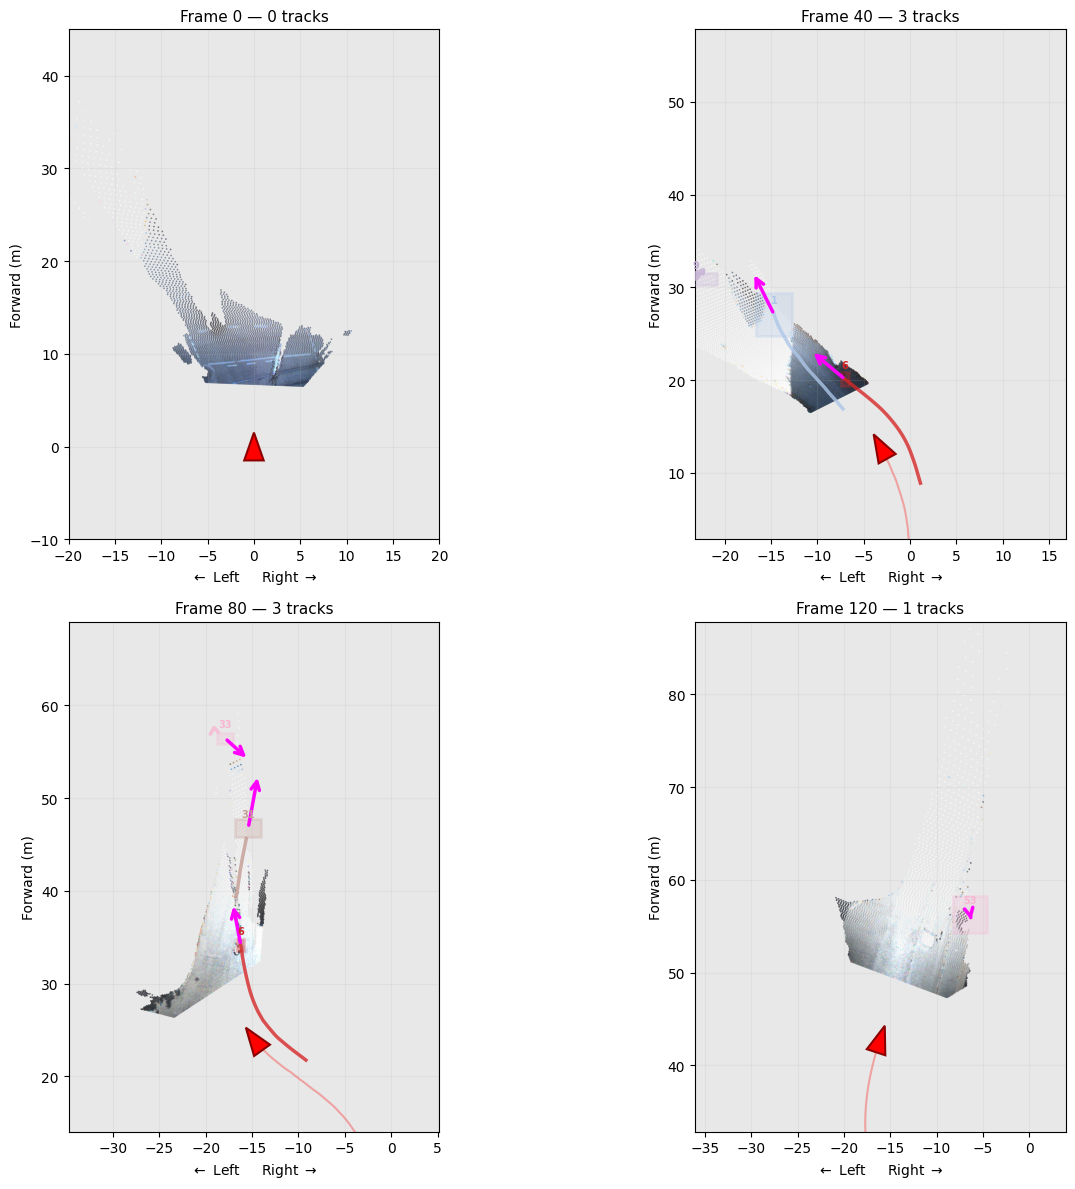

In [14]:
# BEV snapshots at four points in the sequence (plotting code: n3_viz.py)
viz.show_tracking_frames(frame_results, road_bev, road_bev_colors, ego_positions,
                         sample_frames=[0, 40, 80, 120], num_frames=num_frames)

## 7. Tracking Video — BEV + Camera Projection

Render a side-by-side video:
- **Left**: camera image with projected 3D bounding boxes, track IDs, and **magenta prediction arrows** showing where each object will be ~1 s from now
- **Right**: bird's-eye view with trajectory history (solid, track-colored) and the same magenta prediction arrows

The rendering loop lives in `n3_viz.py` (`render_tracking_video`) — it only draws what the tracker already computed: each track's latest 3D box projected through $M_{proj}$, plus the Kalman prediction arrows.

In [15]:
viz.render_tracking_video(data, frame_results, road_bev, road_bev_colors,
                          ego_positions, M_proj, num_frames,
                          out_path='videos/lidar_tracking.mp4')

Rendering 154 frames to video...
  Rendering frame 0/154


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1600, 550) to (1600, 560) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


  Rendering frame 20/154


  Rendering frame 40/154


  Rendering frame 60/154


  Rendering frame 80/154


  Rendering frame 100/154


  Rendering frame 120/154


  Rendering frame 140/154



Saved: videos/lidar_tracking.mp4  (154 frames @ 10 fps)


## Summary

This notebook built a complete 3D LiDAR detection and tracking pipeline from scratch:

1. **Ground removal** — surface normal estimation identifies horizontal surfaces by finding points whose local neighborhood is approximately flat ($|\mathbf{n}_z| > 0.85$)
2. **Euclidean clustering** — DBSCAN groups nearby non-ground points into object candidates
3. **3D bounding boxes** — axis-aligned boxes from cluster extents, filtered by vehicle dimensions
4. **Road filtering** — SegFormer road segmentation (from N1) projects each detection's base onto the camera image and keeps only objects on the drivable surface
5. **Ego-motion compensation** — GPS/IMU poses transform all detections into a fixed world frame, so stationary objects stay still and tracked velocities reflect true object motion
6. **Kalman filter tracking** — the same 4-state $[x, y, v_x, v_y]$ constant-velocity filter from N2, running in the BEV plane, with Hungarian assignment for data association
7. **Future prediction** — extrapolating each track's estimated velocity to forecast where it will be 10 timesteps (~1.1 s) in the future, visualized as magenta arrows on both camera and BEV views

### Key Takeaways

- LiDAR gives **direct 3D measurements** — no monocular depth estimation needed
- Normal filtering is a **geometric** approach to ground removal that generalizes to uneven terrain
- The **Kalman filter from N2 transfers directly**: detect in 3D, track $[x, y, v_x, v_y]$ in the BEV plane — the detection's height and 3D box are kept for visualization, since vehicles don't move vertically
- **Connecting N1 → N3**: semantic road segmentation from camera images filters LiDAR detections to only road-relevant objects — a concrete example of camera–LiDAR fusion
- **Ego-motion compensation** using GPS/IMU ensures prediction arrows show true object trajectories, not artifacts of the car's own motion — the BEV shows a stabilized world view where the ego vehicle moves through the scene

### What's Next

- **N4** — Multi-Object Tracking on camera images with YOLO detections and 2D bounding boxes
- Fusing LiDAR 3D tracks with camera 2D tracks for robust multi-modal perception